---
tags: [tutorial]
---

# `qmc.control`によるゲートとサブカーネルの制御

[チュートリアル03](03_vector_slicing.ipynb)では、`VectorView`スライスを使って、ヘルパーカーネルが大きなレジスタの連続した一部だけに作用できることを示しました。本章では`qmc.control`を扱います。`qmc.control`を使うと、Qamomileの任意のゲート(`qmc.rx`のようなビルトイン関数や、ユーザが書いた`@qmc.qkernel`)の制御版を作れます。

`qmc.control`には2つのモードがあります。*concrete mode*は制御qubitの数をPythonの`int`で与え、*symbolic mode*は`qmc.UInt`のカーネルパラメータ(あるいはそれを含む式)で与えてtranspile時に解決します。`power=`、デフォルト引数、`Vector[Qubit]`を取るサブカーネル、古典kwargの並び替えなど大半の機能は両モードで同じ挙動です。モードによって違うのは制御引数の渡し方と一部の追加機能だけで、以降のセクションで分けて扱います。

In [2]:
# Install the latest Qamomile from pip.
# !pip install qamomile

In [3]:
import math

import qamomile.circuit as qmc
from qamomile.circuit.transpiler.errors import UnreturnedBorrowError
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

(cg-1)=
## 1. 最小例: controlled-RX

`qmc.control`の最も簡単かつ実用的な使い方は、Qamomileで用意されている1つのゲートを制御化することです。例えば以下では、1qubitゲートの`qmc.rx(q, angle)`を`qmc.control`に渡して、2qubitのcontrolled-RXゲートを得ています。

In [9]:
# 制御RXゲートを定義します。
crx = qmc.control(qmc.rx)

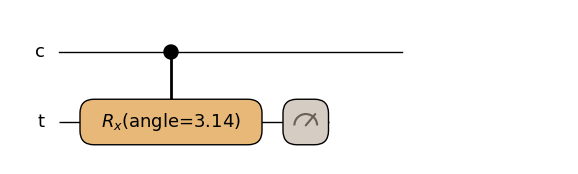

In [10]:
@qmc.qkernel
def crx_control_off() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # 制御は|0>のままなので、制御回転は発火しません。
    
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_control_off.draw()

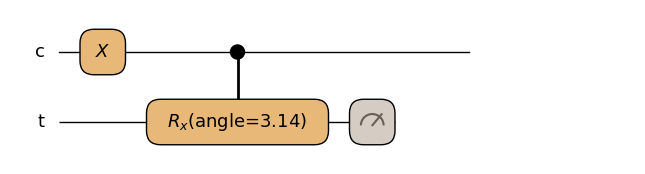

In [11]:
@qmc.qkernel
def crx_control_on() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # 制御を|1>に立てるので、制御回転が発火します。
    c = qmc.x(c)
    crx = qmc.control(qmc.rx)
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_control_on.draw()

制御が実際に効いていることを確かめるために、両方の量子カーネルをQiskitにtranspileしてsimulatorで実行し、targetの測定結果を確認します。`angle=math.pi`では`RX(pi)`が|0>を|1>に写すので、制御が|1>のときだけtargetは全shotで|1>になり、それ以外では|0>のままになります。

In [12]:
off_counts = dict(
    transpiler.transpile(crx_control_off)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
on_counts = dict(
    transpiler.transpile(crx_control_on)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
print("control |0> ->", off_counts)
assert off_counts == {0: 256}
print("control |1> ->", on_counts)
assert on_counts == {1: 256}

control |0> -> {0: 256}
control |1> -> {1: 256}


- `crx = qmc.control(qmc.rx)`はqkernelの中でも外でもどちらに書いてもかまいません。返ってきたものは再利用可能な値なので、変数に置いて何度でも呼び出せます。
- `crx(c, t, angle=...)`を呼ぶと、まず制御qubitがpositional引数として並び、次にtarget、最後に古典keyword引数が続きます。順序は制御化する対象の`qmc.rx(q, angle)`シグネチャを踏襲しつつ、先頭に制御を1つ加えた形です。
- 古典パラメータのkeyword名は制御化する対象の関数の名前をそのまま使います(`qmc.rx`なら`angle`、`qmc.p`なら`theta`など)。`qmc.control`が改名することはありません。

(cg-2)=
## 2. 2つのモードの概要

`qmc.control`には2つのモードがあります。どちらかは`num_controls`に渡す型だけで決まります。Pythonの`int`なら*concrete mode*、`qmc.UInt`ハンドル(あるいは`n - 1`のような`UInt`式)なら*symbolic mode*です。その他の挙動はすべてこの選択から決まります。

| 項目 | Concrete | Symbolic |
| --- | --- | --- |
| `num_controls=` | Pythonの`int`(デフォルト`1`) | `qmc.UInt`ハンドル、または`UInt`式 |
| 制御引数 | 合計qubit数が`num_controls`に一致する1つ以上のpositional引数(`Qubit`、`VectorView`、`Vector[Qubit]`) | 1つのpositionalな`Vector[Qubit]` / `VectorView`の*pool*(single-pool形、任意で`control_indices=`)、**または**`Qubit` / `VectorView` / `Vector[Qubit]`を混ぜた複数のpositional引数(multi-arg形、[](#cg-5-5)) |
| `control_indices=` | 受け付けない | 任意。poolのどのスロットがactiveかを指定 |
| 制御数が解決される時点 | `qmc.control(...)`が評価された時(module load時かtracing時) | transpile時(`bindings`から) |

判断ルールはシンプルです。qkernelを書く時点で制御数がリテラルとしてわかっており、各制御qubitを個別に名指ししたい場合は*concrete mode*を使います。制御数がカーネルパラメータ(またはそれを含む式、`num_controls=n - 1`は典型的なmulti-controlledの形)の場合は*symbolic mode*を使います。

`qmc.control`のほとんどの機能(`power=`、デフォルト値、古典kwargの並び替え、`Vector[Qubit]`を受け取るサブカーネルなど)は両モードで同じ挙動を示します。これらは[](#cg-3)でまとめます。[](#cg-4)はmulti-argの制御引数形(簡潔さのためconcrete modeで例示しますが、symbolicでも動きます)を、[](#cg-5)はsymbolic mode固有の機能を扱います。

(cg-3)=
## 3. 両モードで動作するパターン

本セクションの各機能は、どちらのモードでも同じ挙動を示します。以下のセルはconcrete modeを使います(`UInt`のカーネルパラメータが入らない分、コードが短くなるためです)が、同じ機能はsymbolic modeでも利用可能です。symbolic modeはsingle-poolの制御引数形([](#cg-5-1) – [](#cg-5-4))とmulti-arg形([](#cg-5-5))の両方を受け付けます。concrete modeと違うのは`num_controls`が`UInt`式であることと、qubit数の一致がtranspile時にチェックされることだけです。各モードの引数形は[](#cg-4)と[](#cg-5)で詳しく扱います。本セクションは*挙動*がモードに依存しない機能を集めたものです。

(cg-3-1)=
### 3.1 任意のcallableを制御化

`qmc.control`はビルトインのゲート関数(`qmc.rx`、`qmc.h`、`qmc.p`など)も、ユーザ定義の`@qmc.qkernel`も同様に受け付けます。`qmc.control`はどちらかを気にしません。制御化する対象のcallableのシグネチャを見て、量子オペランドと古典パラメータを取り出し、残りをcontrolled-Uで包んでemitします。以下の例では、`ch`が単一のプリミティブを制御化し、`cg`がゲートを2つ含むユーザ定義のカーネル本体を制御化しています。

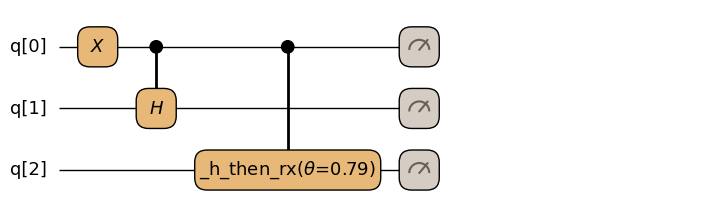

In [4]:
@qmc.qkernel
def _h_then_rx(q: qmc.Qubit, theta: qmc.Float) -> qmc.Qubit:
    q = qmc.h(q)
    q = qmc.rx(q, theta)
    return q


@qmc.qkernel
def control_any_callable_demo() -> qmc.Vector[qmc.Bit]:
    # q[0]は共通の制御。q[1] / q[2]は2つのtarget。
    q = qmc.qubit_array(3, "q")
    q[0] = qmc.x(q[0])
    ch = qmc.control(qmc.h)  # ビルトインのゲート関数
    q[0], q[1] = ch(q[0], q[1])
    cg = qmc.control(_h_then_rx)  # ユーザの@qmc.qkernel
    q[0], q[2] = cg(q[0], q[2], theta=math.pi / 4)
    return qmc.measure(q)


control_any_callable_demo.draw()

(cg-3-2)=
### 3.2 `Vector[Qubit]`を受け取るサブカーネル

制御化する対象のカーネルは`Vector[Qubit]`引数を取れます。呼び出し側は長さの一致する`Vector`または`VectorView`を渡します。controlled-Uのemit passはこのvectorオペランドを物理target qubitに解決し、内部ブロックをbackendに渡します。Qiskitはcontrolled block全体を1つのnativeゲートとしてemitし、CUDA-Qはブロック内の各ゲートを個別に制御化します。ただし、すべてのbackendが複数qubitの内部ブロックをこの形で制御化できるわけではありません。QuriPartsは上記のmulti-targetケースを明確な`EmitError`でrejectするので、その場合はQiskitかCUDA-Qで実行してください。いずれの場合も呼び出し側は同じで、qubit毎にオペランドを書き並べる必要はありません。

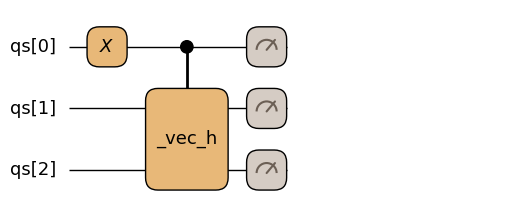

In [5]:
@qmc.qkernel
def _vec_h(qs: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    qs[0] = qmc.h(qs[0])
    qs[1] = qmc.h(qs[1])
    return qs


@qmc.qkernel
def vec_target_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(3, "qs")
    qs[0] = qmc.x(qs[0])
    cg = qmc.control(_vec_h, num_controls=1)
    qs[0], qs[1:3] = cg(qs[0], qs[1:3])
    return qmc.measure(qs)


vec_target_demo.draw()

(cg-3-3)=
### 3.3 制御化する対象カーネルのシグネチャ由来のデフォルト値

制御化する対象の`@qmc.qkernel`が古典パラメータにPythonのデフォルト値を宣言している場合、呼び出し側ではそのkeywordを省略するか、callsiteでpositionalに上書きするかのどちらでもよいです。`qmc.control`は欠けた値を`inspect.Signature.bind + apply_defaults`で補完するので、解決後の値は通常の直接呼び出しと同じようにcontrolled-Uまで届きます(デフォルト値を持てるのは`@qmc.qkernel`のcallableだけです。plain Python関数で同じことを試した場合の挙動は[](#cg-6-7)を参照してください)。

どちらの形もどちらのモードでも使えます。以下のセルはまずconcrete modeで省略形を示し、続いて同じ省略形をsymbolic modeで繰り返して「両モードでデフォルトが効く」がconcrete専用の便宜ではなく実際に動くことを明示します。

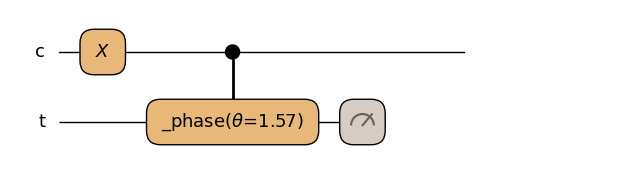

In [6]:
@qmc.qkernel
def _phase(q: qmc.Qubit, theta: qmc.Float = math.pi / 2) -> qmc.Qubit:
    return qmc.rx(q, theta)


@qmc.qkernel
def default_arg_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_phase)
    c, t = cg(c, t)  # thetaはデフォルトのmath.pi / 2が入る
    return qmc.measure(t)


default_arg_demo.draw()

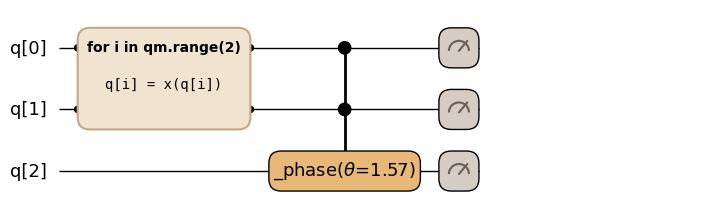

In [7]:
# 同じ`_phase`カーネルを、今度はsymbolicな`num_controls=n - 1`で制御化
# します。呼び出し側が`theta`を名指ししなくても`theta=math.pi / 2`の
# デフォルトはそのまま適用されます。別の角度を使いたいがkwargには
# 切り替えたくない場合は、省略した`theta`をcallsiteのpositional上書き
# (`cg(q[0 : n - 1], q[n - 1], math.pi / 4)`)に置き換えます。
@qmc.qkernel
def default_arg_demo_symbolic(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, "q")
    for i in qmc.range(n - 1):
        q[i] = qmc.x(q[i])  # 全ての制御slotを|1>にする
    cg = qmc.control(_phase, num_controls=n - 1)
    q[0 : n - 1], q[n - 1] = cg(q[0 : n - 1], q[n - 1])
    return qmc.measure(q)


default_arg_demo_symbolic.draw(n=3)

(cg-3-4)=
### 3.4 古典keyword引数を任意の順序で

呼び出し側の古典kwargは名前で照合され、制御化する対象カーネルが宣言した順序に並べ替えられます。そのため、kwargをどちらの順序で書いても同じ回路にコンパイルされます。セル末尾のassertionは、transpileしたQiskit回路を文字列レベルで比較してそれを明示的に検証しています。

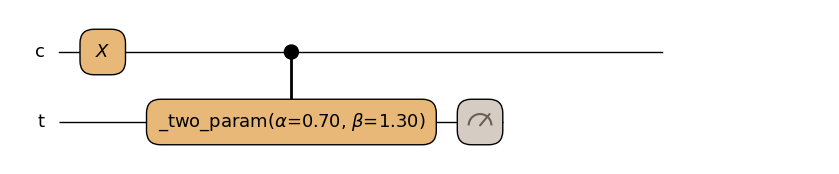

In [7]:
@qmc.qkernel
def _two_param(q: qmc.Qubit, alpha: qmc.Float, beta: qmc.Float) -> qmc.Qubit:
    q = qmc.rx(q, alpha)
    q = qmc.rz(q, beta)
    return q


@qmc.qkernel
def kwargs_in_order() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_two_param)
    c, t = cg(c, t, alpha=0.7, beta=1.3)
    return qmc.measure(t)


@qmc.qkernel
def kwargs_reversed() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(_two_param)
    c, t = cg(c, t, beta=1.3, alpha=0.7)
    return qmc.measure(t)


exe_a = transpiler.transpile(kwargs_in_order)
exe_b = transpiler.transpile(kwargs_reversed)
assert str(exe_a.compiled_quantum[0].circuit) == str(exe_b.compiled_quantum[0].circuit)

kwargs_in_order.draw()

(cg-3-5)=
### 3.5 `power=`で`U^k`を制御

`power=k`を渡すと、`U`そのものではなく*k乗*の`U^k`が制御されます。これはQPEで標準的に使われるパターンで、j番目のレジスタはcontrolled-`U^(2**j)`を適用します。`power`はPythonの`int`(コンパイル時に解決)も`qmc.UInt`ハンドル(`bindings`からtranspile時に解決)も受け取り、`num_controls`がconcreteかsymbolicかに関係なく動作します。両方の形を並べて示します。

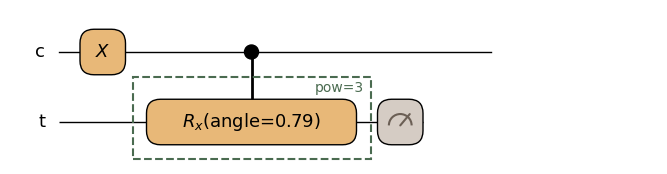

In [8]:
@qmc.qkernel
def power_demo_concrete() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(qmc.rx)  # num_controls = 1 (concrete)
    c, t = cg(c, t, angle=math.pi / 4, power=3)  # powerはPythonのint
    return qmc.measure(t)


@qmc.qkernel
def power_demo_symbolic(k: qmc.UInt) -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    cg = qmc.control(qmc.rx)
    c, t = cg(c, t, angle=math.pi / 4, power=k)  # powerはUIntハンドル
    return qmc.measure(t)


power_demo_concrete.draw()

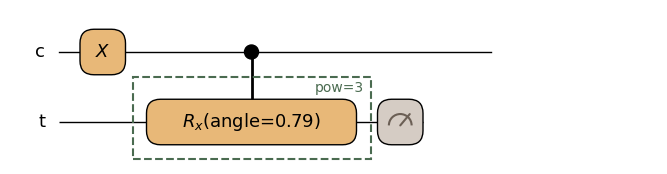

In [9]:
# symbolic power側はdraw / transpile前に`k`の束縛が必要です。
power_demo_symbolic.draw(k=3)

(cg-4)=
## 4. 複数のpositional制御引数 (concrete mode)

本セクションの形は、各制御を別々のpositional引数として並べます。ここでは各制御のqubit数がリテラルになるconcrete modeで示しますが、これらはconcrete**専用ではありません**。symbolic modeも同じmulti-argの制御prefixを受け付けます([](#cg-5-5)がまさにこれらの形を`UInt`の`num_controls`に持ち上げています)。concrete modeは単に導入が一番短くなるというだけです。

唯一の本当にconcrete専用の形は、[](#cg-1)の最小の単一scalar制御です。symbolic modeは単一の制御引数をpoolと読んで`Vector` / `VectorView`を要求するため、単一の固定scalar制御はconcrete modeで書きます(symbolicで渡したときのエラーは[](#cg-6-10)を参照)。

(cg-4-1)=
### 4.1 制御引数を別々のpositionalで渡す(CCXスタイル)

`num_controls=2`にすると、呼び出し側では各制御qubitをそれぞれ独立したpositional引数としてtargetの前に並べます。以下は典型的なCCX(Toffoli)で、2つの制御`c0`、`c1`と1つのtarget`t`を渡しています。同じパターンは`num_controls=3`(CCCX)や`num_controls=4`にも拡張でき、渡したい`Qubit`ハンドルがその数だけあれば成立します。

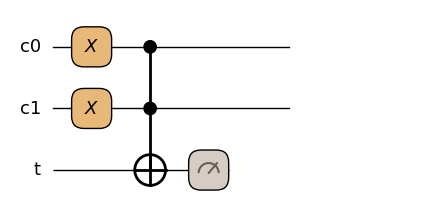

In [10]:
@qmc.qkernel
def toffoli_demo() -> qmc.Bit:
    c0 = qmc.qubit(name="c0")
    c1 = qmc.qubit(name="c1")
    t = qmc.qubit(name="t")
    c0 = qmc.x(c0)
    c1 = qmc.x(c1)
    ccx = qmc.control(qmc.x, num_controls=2)
    c0, c1, t = ccx(c0, c1, t)
    return qmc.measure(t)


toffoli_demo.draw()

(cg-4-2)=
### 4.2 scalar Qubitと`VectorView`の制御を混ぜる

concrete modeのpositional制御prefixは、合計qubit数が`num_controls`と一致する限り、scalarな`Qubit`ハンドル、`VectorView`スライス、`Vector[Qubit]`全体を自由に混ぜられます。以下では`num_controls=3`のcontrolled-Hに対し、3つの制御を`qs[0]`(scalar `Qubit`、1qubit)と`qs[1:3]`(`VectorView`、2qubit)で供給しています。symbolic modeも同じ自由度をmulti-argの形([](#cg-5-5))で提供します。

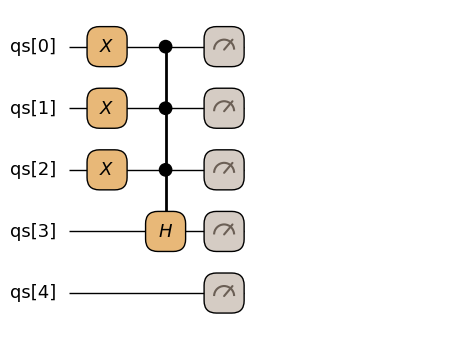

In [11]:
@qmc.qkernel
def mixed_controls_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(5, "qs")
    qs[0] = qmc.x(qs[0])
    qs[1] = qmc.x(qs[1])
    qs[2] = qmc.x(qs[2])
    cg = qmc.control(qmc.h, num_controls=3)
    qs[0], qs[1:3], qs[3] = cg(qs[0], qs[1:3], qs[3])
    return qmc.measure(qs)


mixed_controls_demo.draw()

(cg-5)=
## 5. Symbolic modeのパターン

本セクションは`num_controls`が`qmc.UInt`ハンドル(または`n - 1`のような`UInt`式)のときに何が得られるかを扱います。activeな制御の数は`qmc.control(..., num_controls=...)`の評価時ではなく、`bindings`からtranspile時に決まります。以下のうち本当にsymbolic専用なのは、長さがsymbolicなpoolと`control_indices=`です。[](#cg-5-5)のmulti-argの形は、[](#cg-4)のconcreteなデモのsymbolic版にすぎません。

制御側のcall-site形は2種類サポートされます。

- **Single-poolの形**([](#cg-5-1) – [](#cg-5-4)): 制御引数として`Vector[Qubit]`または`VectorView`を1つ渡し、pool全体、もしくは`control_indices=`で選んだsubsetがactiveな制御として配線されます。
- **Multi-argの形**([](#cg-5-5)): 制御prefixが複数のpositional引数(scalar`Qubit`、`VectorView`スライス、`Vector[Qubit]`全体、またはこれらの組み合わせ)で、qubit数の合計が`num_controls`と一致します。concrete modeで既に出ていた形([](#cg-4-1) / [](#cg-4-2))を、symbolicな`num_controls`に持ち上げたものです。

`control_indices=`keywordはsymbolic mode専用で、single-poolの引数のどのスロットがactiveな制御として実際に配線されるかを指定します(残りはそのまま素通りします)。`control_indices=`はsingle-poolの形でのみ有効で、multi-argの形と組み合わせるとcompose時にrejectされます。

(cg-5-1)=
### 5.1 `num_controls = n`でpool全体を制御に

最もシンプルなsymbolicの形で、`num_controls=n`としてpool(長さ`n`)全体をactiveな制御として使います。カーネルパラメータ`n`は`bindings`からtranspile時に具体化されます。controlled-gate自体の形は`n`が束縛されれば適応しますが、以下のデモでは`n=3`を束縛しています。本体が`ctrls[0]`、`ctrls[1]`、`ctrls[2]`を`qmc.x`で初期化しているため、`n < 3`はインデックス範囲外、`n > 3`は一部のpoolスロットが`|0>`のまま残ります(transpile自体は成功しますが、デモが意図する「全制御がactive」という状態は満たせなくなります)。`n`に対応してスケールする本体にしたい場合は、固定の初期化をループに置き換えてください。

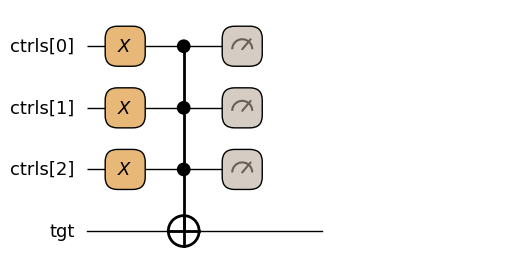

In [12]:
@qmc.qkernel
def symbolic_pool(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    ctrls = qmc.qubit_array(n, "ctrls")
    tgt = qmc.qubit(name="tgt")
    ctrls[0] = qmc.x(ctrls[0])
    ctrls[1] = qmc.x(ctrls[1])
    ctrls[2] = qmc.x(ctrls[2])
    cg = qmc.control(qmc.x, num_controls=n)
    ctrls, tgt = cg(ctrls, tgt)
    return qmc.measure(ctrls)


symbolic_pool.draw(n=3)

(cg-5-2)=
### 5.2 `n - 1`の典型的なmulti-controlled形

multi-controlled-X設計で頻出する形で、レジスタの最初の`n - 1`qubitを制御に、最後の1qubitをtargetにします。`num_controls`の値はsymbolic式の`n - 1`で、制御引数はスライス`qs[0:n - 1]`です。

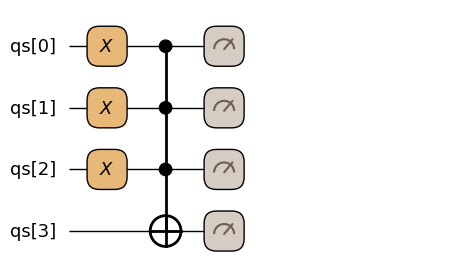

In [13]:
@qmc.qkernel
def mcx_demo(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(n, "qs")
    qs[0] = qmc.x(qs[0])
    qs[1] = qmc.x(qs[1])
    qs[2] = qmc.x(qs[2])
    mcx = qmc.control(qmc.x, num_controls=n - 1)
    qs[0 : n - 1], qs[n - 1] = mcx(qs[0 : n - 1], qs[n - 1])
    return qmc.measure(qs)


mcx_demo.draw(n=4)

(cg-5-3)=
### 5.3 `control_indices=`でsubsetを選ぶ

制御poolがactiveな制御数より広い場合、`control_indices=`keyword(symbolic mode専用)でpoolのどのスロットを配線するかを指定します。残りのスロットはそのまま素通りで、wire上には残りますが追加のゲートはemitされません。indexは連続である必要はありません。

以下の例では、poolは4qubitですが、3つのactiveな制御は`pool[0]`、`pool[1]`、`pool[3]`(`control_indices=[0, 1, 3]`)です。`pool[2]`は同行しているだけで、controlのdotは描かれず、MCXの縦の接続線も`pool[2]`をスキップして描かれます。

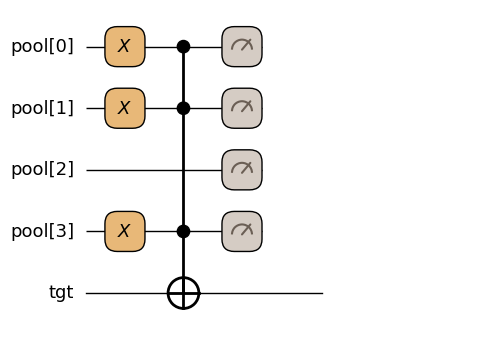

In [14]:
@qmc.qkernel
def subset_pool(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[3] = qmc.x(pool[3])  # pool[2]は|0>のまま。これがinactiveなスロット。
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, control_indices=[0, 1, 3])
    return qmc.measure(pool)


subset_pool.draw(n=4, k_ctrls=3)

(cg-5-4)=
### 5.4 `control_indices`に`UInt`式を含める

`control_indices`の各エントリはPythonの`int`リテラル、`qmc.UInt`ハンドル、または`UInt`値による算術式のいずれでも構いません。リテラル`int`エントリに対する軽い構造チェック(`bool`、負値、リテラル`int`同士の重複の拒否)はcompose時に行われますが、それ以外、すなわち`num_controls`との長さ整合、pool sizeに対する範囲、`UInt`の値解決を必要とするチェックはtranspile時、`bindings`からパラメータが具体化されてからに先送りされます。

以下では3つ目のactiveな制御を`pool[n - 1]`、つまり「poolの最後のスロット」を`UInt`算術で表現しています。`n = 4`ではスロット3に解決され、`pool[2]`はinactiveのまま残ります。コンパイル後の回路は[](#cg-5-3)と同じで、indexの書き方だけが違います。

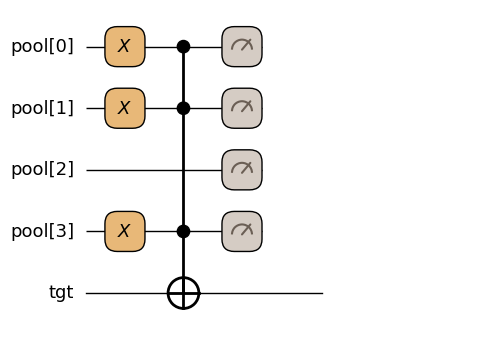

In [15]:
@qmc.qkernel
def subset_pool_with_uint(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[3] = qmc.x(pool[3])
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, control_indices=[0, 1, n - 1])
    return qmc.measure(pool)


subset_pool_with_uint.draw(n=4, k_ctrls=3)

(cg-5-5)=
### 5.5 Multi-argの制御prefix

制御を複数のpositional引数に分けたい場合、典型的には「同じ`Vector`のいくつかのスロットをactiveな制御に、別のスロットをtargetに」したいときに、symbolic modeでもconcrete modeと同じmulti-argの形([](#cg-4-1) / [](#cg-4-2))が使えます。同じ`Vector[Qubit]`から複数のスロットを取り出しても、互いにdisjoint(重ならない)なスロットであれば制御prefixに並べられます。制御prefixの各引数のqubit数の合計が、transpile時に`num_controls`と照合されます。

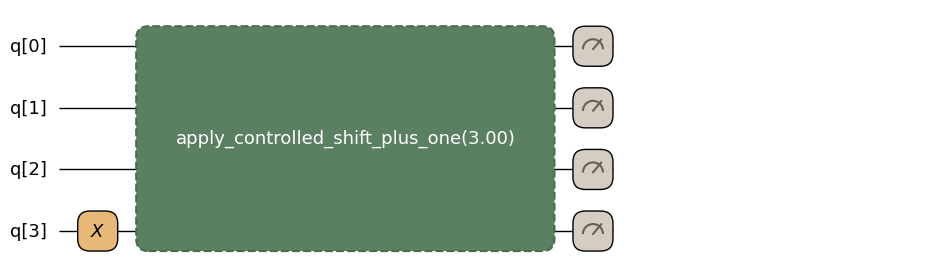

In [16]:
@qmc.qkernel
def apply_controlled_shift_plus_one(
    q: qmc.Vector[qmc.Qubit], control_index: qmc.UInt
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for k in qmc.range(n - 1):
        target_idx = n - 2 - k
        ctrl_main = q[control_index]
        prefix = q[0:target_idx]
        tgt = q[target_idx]
        cg = qmc.control(qmc.x, num_controls=target_idx + 1)
        ctrl_main, prefix, tgt = cg(ctrl_main, prefix, tgt)
        q[control_index] = ctrl_main
        q[0:target_idx] = prefix
        q[target_idx] = tgt
    return q


@qmc.qkernel
def controlled_increment_demo(
    n: qmc.UInt, control_index: qmc.UInt
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, "q")
    q[control_index] = qmc.x(q[control_index])  # gatingビットを|1>にする
    q = apply_controlled_shift_plus_one(q, control_index)
    return qmc.measure(q)


controlled_increment_demo.draw(n=4, control_index=3)

Multi-argの形について補足:

- Call-siteの引数は、制御化する対象のkernelのシグネチャから「制御prefix」と「sub-kernel positional」に分割されます。kwargsで指定されていないpositionalパラメータはすべてpositionalで届く必要があり、その末尾のブロックより*前*が制御prefixです。上記の例では`qmc.x`が1つの`Qubit` positionalを取るので、最後の引数(`tgt`)がtarget、最初の2つ(`ctrl_main`、`prefix`)が制御になります。
- Borrow trackerは、別々の引数が触るスロットが互いにdisjointである限り満たされます。静的なdisjointnessは境界がリテラルなときにcheckされ、symbolic境界(`q[0:target_idx]`と`q[target_idx]`と`q[control_index]`)はtrackerがregister partition向けにすでにサポートしているbound predicatesに任せます。
- `control_indices=`はmulti-argの形ではrejectされます([](#cg-6)のreject caseを参照)。subset選択が必要ならsingle-poolの形([](#cg-5-3) / [](#cg-5-4))、 multi-argの自由度が必要ならprefix全体をactiveとして使うか、 のどちらかを選んでください。

(cg-6)=
## 6. 動かないパターン

以下の各セルはrejectされる呼び出し形を1つずつ試し、想定例外型を小さな`expect_error`ヘルパでassertします。ヘルパは*想定*の例外クラスだけをcatchし、それ以外の例外は通常のセルエラーとしてそのまま伝播するので、別の例外型が飛ぶようなregressionはnotebook上のtracebackですぐに目に入ります。例外が一度も発生しなかった場合は`AssertionError`を投げます。「Mode」列は各拒否が`qmc.control`のどのモードで起きるかを示します。

| ケース | モード | 例外 |
| --- | --- | --- |
| 6.1 制御qubit数が引数境界をまたぐ | concrete | `ValueError` |
| 6.2 concrete modeで`control_indices=` | concrete | `ValueError` |
| 6.3 concrete modeでsymbolic長の`VectorView` | concrete | `NotImplementedError` |
| 6.4 古典kwargのtypo | 両方 | `TypeError` |
| 6.5 不正な`power`(0または`bool`) | 両方 | `ValueError` / `TypeError` |
| 6.6 `num_controls=0`のリテラル | concrete | `ValueError` |
| 6.7 plain関数にPythonのデフォルト値 | 両方 | `TypeError` |
| 6.8 同じpoolスロットをtargetに再利用 | symbolic | `UnreturnedBorrowError` |
| 6.9 multi-arg制御prefix + `control_indices=` | symbolic | `ValueError` |
| 6.10 symbolic modeで単一scalar制御 | symbolic | `ValueError` |

In [17]:
def expect_error(label: str, exc_type: type, body) -> None:
    """``body``が``exc_type``の例外を投げることをassertします。

    ヘルパは*想定*の例外クラスだけをcatchします。それ以外の
    例外はそのまま伝播するので、別の例外型に変わってしまうような
    regressionはnotebook上で通常のtracebackとして見えます。
    例外が一度も発生しなかった場合は``AssertionError``を投げます。
    """
    try:
        body()
    except exc_type as exc:
        print(f"[{type(exc).__name__}] {label}: {exc}")
        return
    raise AssertionError(
        f"{label}: expected {exc_type.__name__}, but no exception was raised"
    )

(cg-6-1)=
### 6.1 制御qubit数が引数境界をまたぐ (concrete)

concrete modeはpositional引数を左から右に歩いて、各引数を制御リストに畳み込み、累計が`num_controls`に達するまで続けます。途中の引数が累計を`num_controls`を*超えて*押し込む(以下の例は`num_controls=3`に対して5qubitのスライスを渡す)場合、その呼び出しはcompose時に`ValueError`でrejectされます。引数を境界で綺麗に分割するよう促す形です。

(同じ間違いの*too-narrow*版、つまり制御qubitを`num_controls`より少なく渡したケースは、見た目が違います。targetのつもりだった追加のpositional引数が制御リストに畳み込まれてしまい、`qmc.control`が「targetが残っていない」と苦情を言います。これはPython側の`TypeError: missing a required argument`であって、controlled-Uの`ValueError`ではありません。)

In [18]:
def case_count_mismatch() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        qs = qmc.qubit_array(6, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, t = cg(qs[0:5], qs[5])  # 5qubit渡しているが3expected
        qs[0:5] = view
        return qmc.measure(qs[5])

    _ = kernel.block


expect_error("control count mismatch", ValueError, case_count_mismatch)

[ValueError] control count mismatch: concrete num_controls=3: positional argument #0 would push the control qubit count from 0 to 5, crossing the control / sub-kernel boundary mid-argument.  Split the argument so the boundary falls between args.


(cg-6-2)=
### 6.2 concrete modeで`control_indices=` (concrete)

`control_indices`は選択元となる制御*pool*がある時にだけ意味を持つ、symbolic modeの概念です。concreteな`num_controls`と一緒に渡すと、compose時に`ValueError`になります。

In [19]:
def case_control_indices_in_concrete() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)  # num_controlsはデフォルトの1 (concrete)
        c, t = cg(c, t, control_indices=[0])
        return qmc.measure(t)

    _ = kernel.block


expect_error(
    "control_indices in concrete mode",
    ValueError,
    case_control_indices_in_concrete,
)

[ValueError] control_indices in concrete mode: control_indices is only valid in symbolic mode (num_controls=UInt).  Got concrete num_controls; concrete-mode controls are positional and have no selection step (see design §1.1).


(cg-6-3)=
### 6.3 concrete modeでsymbolic長の`VectorView` (concrete)

concrete modeは各制御引数のqubit数をコンパイル時に決定する必要があります。長さが`UInt`に依存するスライス(以下は`m`がsymbolicな`qs[0:m]`)はconcrete modeでは未対応で、`NotImplementedError`になります。workaroundはsymbolic modeへの切り替えです。`num_controls=m`と`cg(qs, t)`なら、この形をそのまま受け付けます([](#cg-5-1)参照)。

In [20]:
def case_symbolic_view_in_concrete() -> None:
    @qmc.qkernel
    def kernel(m: qmc.UInt) -> qmc.Bit:
        qs = qmc.qubit_array(m, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, q_out = cg(qs[0:m], qs[m - 1])
        qs[0:m] = view
        qs[m - 1] = q_out
        return qmc.measure(qs[m - 1])

    _ = kernel.block


expect_error(
    "symbolic-length VectorView in concrete mode",
    NotImplementedError,
    case_symbolic_view_in_concrete,
)

[NotImplementedError] symbolic-length VectorView in concrete mode: concrete num_controls with a symbolic-length Vector / VectorView control is not yet implemented in the frontend (tracked under Step 2.b of the controlled-API redesign).


(cg-6-4)=
### 6.4 古典keyword引数のtypo (両方)

`qmc.control`は制御化する対象カーネルのシグネチャを参照するので、未知のkeyword名はcompose時に検知されます。エラーメッセージは`qmc.control`が実際に理解するパラメータの一覧を含みます。

In [21]:
def case_kwarg_typo() -> None:
    @qmc.qkernel
    def _gate(q: qmc.Qubit, angle: qmc.Float) -> qmc.Qubit:
        return qmc.rx(q, angle)

    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(_gate)
        c, t = cg(c, t, agnle=0.5)  # typo: agnle -> angle
        return qmc.measure(t)

    _ = kernel.block


expect_error("classical kwarg typo", TypeError, case_kwarg_typo)

[TypeError] classical kwarg typo: control(): unknown parameter(s) ['agnle']. The wrapped kernel's classical parameters are ['angle'].


(cg-6-5)=
### 6.5 不正な`power` (両方)

`power`は厳密に正の整数(`int`または`qmc.UInt`)である必要があります。0と負値は`ValueError`を投げます。Pythonの`bool`は`TypeError`としてrejectし、`power=True`が暗黙に`power=1`と解釈されないようにしています。この制約はconcrete modeでもsymbolic modeでも同じです。

In [22]:
def case_power_zero() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)
        c, t = cg(c, t, power=0)
        return qmc.measure(t)

    _ = kernel.block


def case_power_bool() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)
        c, t = cg(c, t, power=True)
        return qmc.measure(t)

    _ = kernel.block


expect_error("power=0", ValueError, case_power_zero)
expect_error("power=True (bool)", TypeError, case_power_bool)

[ValueError] power=0: power must be a strictly positive integer, got 0.
[TypeError] power=True (bool): power must be a positive integer, got bool (True). Use an integer value like power=1 or power=2.


(cg-6-6)=
### 6.6 `num_controls=0`のリテラル (concrete)

制御が0個の制御ゲートは、要するに元のゲートそのものなので、制御化が意味をなしません。引数がPythonの`int < 1`の場合、`qmc.control`はその評価の瞬間に`ValueError`でrejectします(負の`int`も同様にrejectされます)。一方、`qmc.UInt`ハンドルが0に*解決される*ケースは別物で、`qmc.control`は評価時には値を見ません。0が後段で検知されるかどうかは制御引数の形とbackendに依存します。Qiskitはvalidationまたはbackend側のエラーとして表面化させますが、backendによっては(QuriParts)エラーを出さずに退化した回路をemitします。安全のため、symbolicな`num_controls`は必ず自分で厳密に正の値に束縛してください。

In [23]:
def case_num_controls_zero() -> None:
    qmc.control(qmc.x, num_controls=0)


expect_error("num_controls=0", ValueError, case_num_controls_zero)

[ValueError] num_controls=0: num_controls must be >= 1, got 0.


(cg-6-7)=
### 6.7 plain関数にPythonのデフォルト値 (両方)

`qmc.control`に渡すcallableが`@qmc.qkernel`ではなく、ただのplain Python関数の場合、`qmc.control`はその場でカーネルを自動合成します。合成側はPython側のデフォルト値をIRレベルのデフォルトに変換できないので、デフォルト値を持つplain関数は`qmc.control(...)`を呼んだ瞬間にrejectされます。直し方は、関数を`@qmc.qkernel`としてマークする(デフォルトはend-to-endで追跡されます)か、デフォルトを外して値を呼び出し側で明示的に渡すかのいずれかです。

In [24]:
def case_plain_fn_with_default() -> None:
    def _bad_sub(q: qmc.Qubit, theta: qmc.Float = 0.5) -> qmc.Qubit:
        return qmc.rx(q, theta)

    qmc.control(_bad_sub)


expect_error("plain function with default value", TypeError, case_plain_fn_with_default)

[TypeError] plain function with default value: control(): parameter 'theta' of '_bad_sub' has a default value (0.5), which the wrapper synthesizer does not propagate. Wrap the function in @qmc.qkernel manually.


(cg-6-8)=
### 6.8 同じpoolスロットをtargetに再利用 — single-poolの形 (symbolic)

single-poolの形(`cg(pool, ...)`に`control_indices=`を組み合わせる場合)で、pool内のinactiveなスロットを取り出してtargetとして渡したくなることがあります。例えば`cg(pool, pool[2], control_indices=[0, 1, 3])`として`pool[2]`をcontrolled-Uのtargetにする、といった形です。この呼び出しはlinear typeのborrow trackerによってrejectされます。poolが1引数として消費されている最中に`pool[2]`が別引数として借り出されるため、compose時に`UnreturnedBorrowError`として表面化します。

Workaround(推奨順):

1. **Multi-arg symbolicの形([](#cg-5-5))。** 各スロットまたはsub-viewを別々のpositional引数として渡します。`cg(pool[0], pool[1], pool[3], pool[2])`(またはcontrolled-incrementの例のようにscalar / sliceを混ぜる形)。各引数は`pool`からの別borrowで、borrow trackerがdisjointnessをcheckし、`num_controls`はtranspile時にqubit数の合計と照合されます。
2. **Concrete mode([](#cg-4-2))。** `num_controls`がPythonの`int`なら、同じmulti-argの形がsymbolicの仕組みなしでそのまま動きます。

In [25]:
def case_pool_slot_as_target() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(n, "pool")
        cg = qmc.control(qmc.x, num_controls=k_ctrls)
        pool, q = cg(pool, pool[2], control_indices=[0, 1, 3])
        pool[2] = q
        return qmc.measure(pool)

    _ = kernel.block


expect_error(
    "same-pool slot reused as target",
    UnreturnedBorrowError,
    case_pool_slot_as_target,
)

[UnreturnedBorrowError] same-pool slot reused as target: Array 'pool' has unreturned borrowed elements.
Borrowed elements: pool[2]

Fix: Write back all borrowed elements before using the array:
  q = pool[i]
  q = qm.h(q)
  pool[i] = q  # Return the element


(cg-6-9)=
### 6.9 Multi-arg制御prefix + `control_indices=` (symbolic)

symbolic modeの2つの機能は相互排他です。`control_indices=`は単一の制御pool(`Vector`引数1つ)に対してのみ意味を持ち、複数のpositional制御引数と組み合わせるとcompose時に`ValueError`がraiseされます。subset選択とper-slot routingの両方が必要な場合、subset選択ならsingle-poolの形([](#cg-5-3) / [](#cg-5-4))、per-slot routingならmulti-argの形([](#cg-5-5))のどちらかを選んでください(両方は使えません)。

In [26]:
def case_multi_arg_with_control_indices() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt, k: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n, "q")
        ctrl_main = q[0]
        prefix = q[1:k]
        tgt = q[k]
        cg = qmc.control(qmc.x, num_controls=k + 1)
        ctrl_main, prefix, tgt = cg(ctrl_main, prefix, tgt, control_indices=[0, 1, 2])
        q[0] = ctrl_main
        q[1:k] = prefix
        q[k] = tgt
        return qmc.measure(q)

    _ = kernel.block


expect_error(
    "multi-arg + control_indices",
    ValueError,
    case_multi_arg_with_control_indices,
)

[ValueError] multi-arg + control_indices: control_indices is only supported with a single Vector[Qubit] / VectorView[Qubit] control argument (the pool form).  Combining control_indices with multiple positional control args is not supported.


(cg-6-10)=
### 6.10 symbolic modeで単一scalar制御 (symbolic)

単一のscalar `Qubit`制御は、concrete modeが必要になる唯一の形です。symbolic modeでは単一の制御引数はsingle-poolの形と解釈され、`Vector` / `VectorView`が要求されます。scalar1個は制御数が1に固定されるためsymbolicな意味を持ちません。これを渡すとcompose時に`ValueError`でrejectされ、concrete modeを使う(または制御引数をもう1つ足す)よう促されます。[](#cg-1)の最小controlled-RXは、まさにこの形をconcrete modeで正しく書いたものです。

In [28]:
def case_single_scalar_control_symbolic() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt) -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.rx, num_controls=n)
        c, t = cg(c, t, angle=math.pi)
        return qmc.measure(t)

    _ = kernel.block


expect_error(
    "single scalar control in symbolic mode",
    ValueError,
    case_single_scalar_control_symbolic,
)

[ValueError] single scalar control in symbolic mode: When num_controls is symbolic (UInt), a single control argument must be a Vector[Qubit] / VectorView pool, not a scalar Qubit.  A single fixed scalar control has no symbolic meaning (the count is one), so use concrete mode instead -- e.g. qmc.control(gate) with the default num_controls=1.  To keep a scalar control in symbolic mode, pass it together with at least one more control argument (the multi-arg form).


(cg-7)=
## 7. まとめ

`qmc.control(fn, num_controls=...)`は再利用可能な`ControlledGate`を返します。正しいメンタルモデルは、2つの別々のAPIではなく、2軸のマトリクスです。

- **モードは`num_controls`の型で決まります。** Pythonの`int`なら*concrete mode*、`qmc.UInt`ハンドル(または`n - 1`のような`UInt`式)なら*symbolic mode*です。
- **ほとんどの機能はモードに依存しません。** 任意のcallable(ビルトインまたは`@qmc.qkernel`)の制御化、`Vector[Qubit]`を受け取るサブカーネル、制御化する対象シグネチャ由来のデフォルト、古典kwargの並び替え、`power=`はすべて両モードで同じ挙動です([](#cg-3))。
- **一部の機能はsymbolic専用です。** 長さがsymbolicな制御poolと`control_indices=`によるsubset選択はsymbolic modeにのみ存在します([](#cg-5))。制御引数の*形*そのもの(単一のpool、またはscalar `Qubit` / `VectorView` / `Vector`を混ぜた複数のpositional引数)は両モードで動き、[](#cg-4)はconcrete modeで、[](#cg-5-5)はsymbolic modeで示します。

実用的な判断ルールとしては、制御数がカーネルパラメータやそれを含む式の場合、特に「最後の1つ以外全部」の典型形`num_controls=n - 1`を含む場合は、迷わず*symbolic mode*を使ってください。制御数がリテラルで、制御対象として個別に名指ししたい特定のqubitがある場合は*concrete mode*を使います。同じ`Vector`内のスロットをcontrolとtargetで分けたい場合はsymbolic mode + multi-arg([](#cg-5-5))が一番自然です。

[](#cg-6)は両モードの検証ルールに対するregression testも兼ねていて、各rejectされる形はそれぞれ想定例外型をassertしています。将来の変更でいずれかのチェックが失われたり変わったりすると、docs buildですぐに目に入ります。